In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path('../data/processed')


In [2]:

it_careers = ['Ingeniería de Sistemas', 'Ingeniería de Software', 'Ciencia de Datos', 'Telecomunicaciones y Redes', 'Ciberseguridad']

df_carreras = pd.read_csv(DATA_PATH / 'carreras_cleaned.csv')
df_carreras = df_carreras[df_carreras['NombreCarrera'].isin(it_careers)]

df_estudiantes = pd.read_csv(DATA_PATH / 'estudiantes_cleaned.csv')
df_inscripciones = pd.read_csv(DATA_PATH / 'inscripciones_cleaned.csv')

# Filtrar inscripciones y estudiantes para que solo pertenezcan a las carreras de IT
it_career_ids = df_carreras['CarreraID'].unique()
df_inscripciones = df_inscripciones[df_inscripciones['CarreraID'].isin(it_career_ids)]
df_estudiantes = df_estudiantes[df_estudiantes['EstudianteID'].isin(df_inscripciones['EstudianteID'])]

print("--- Columnas de Carreras ---")
print(df_carreras.columns.tolist())

print("\n--- Columnas de Inscripciones ---")
print(df_inscripciones.columns.tolist())

display(df_carreras.head(2))
display(df_inscripciones.head(2))

--- Columnas de Carreras ---
['CarreraID', 'NombreCarrera', 'Facultad', 'anio']

--- Columnas de Inscripciones ---
['InscripcionID', 'EstudianteID', 'CarreraID', 'NotaFinal', 'SemestreActual', 'anio']


,CarreraID,NombreCarrera,Facultad,anio
0,1,Ingeniería de Sistemas,Facultad de Ingeniería,2024
1,2,Ingeniería de Software,Facultad de Ingeniería,2024


,InscripcionID,EstudianteID,CarreraID,NotaFinal,SemestreActual,anio
0,1,1,2,73.0,10,2024
1,2,2,5,66.0,6,2024


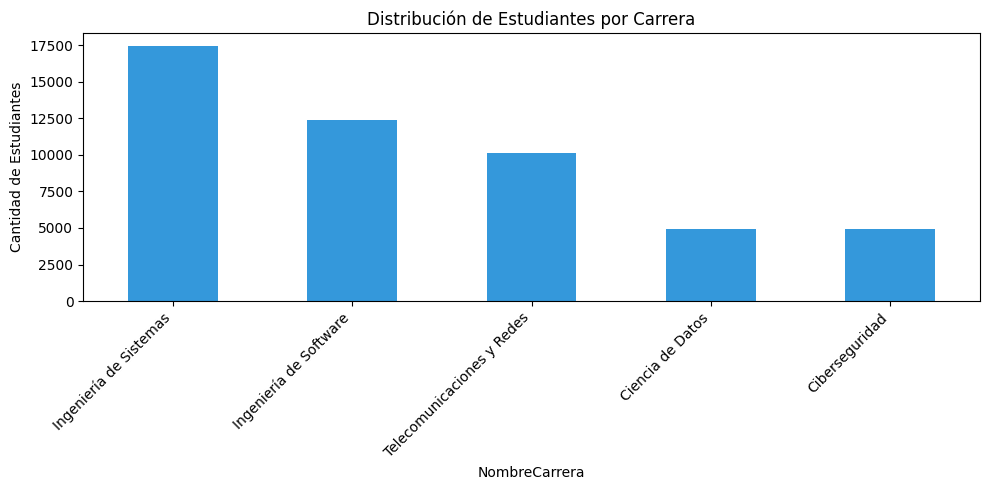

In [3]:
import matplotlib.pyplot as plt

df_task1 = df_estudiantes.merge(df_inscripciones, on='EstudianteID')\
                         .merge(df_carreras, on='CarreraID')
df_task1 = df_task1[['Ciudad', 'NombreCarrera']]

# --- GRÁFICO 1: Por Carrera ---
plt.figure(figsize=(10, 5))
df_task1['NombreCarrera'].value_counts().plot(kind='bar', color='#3498db')
plt.title('Distribución de Estudiantes por Carrera')
plt.ylabel('Cantidad de Estudiantes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


El análisis revela la distribución de estudiantes entre las 5 carreras de IT seleccionadas. En cuanto a la distribución geográfica, se observa la presencia de la matrícula en las principales ciudades de Bolivia.


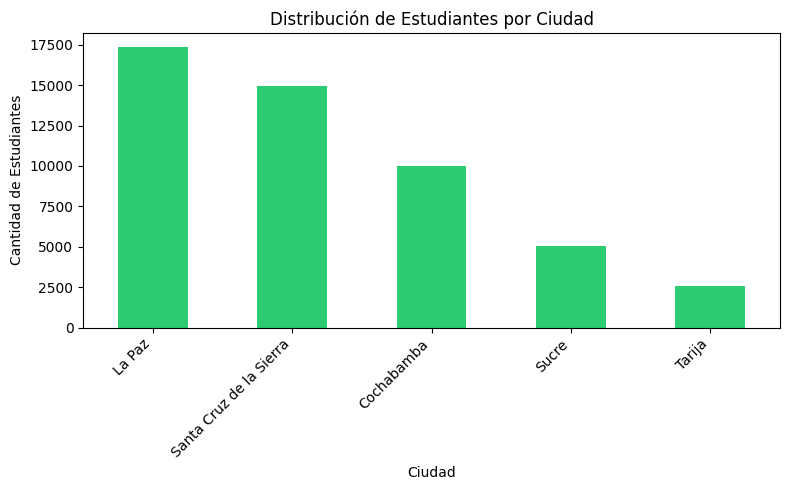

In [4]:
# --- GRÁFICO 2: Por Ciudad ---
plt.figure(figsize=(8, 5))
df_task1['Ciudad'].value_counts().plot(kind='bar', color='#2ecc71')
plt.title('Distribución de Estudiantes por Ciudad')
plt.ylabel('Cantidad de Estudiantes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

En cuanto a la distribución geográfica, la matrícula de carreras de IT se concentra principalmente en los nodos regionales con mayor demanda de infraestructura digital.

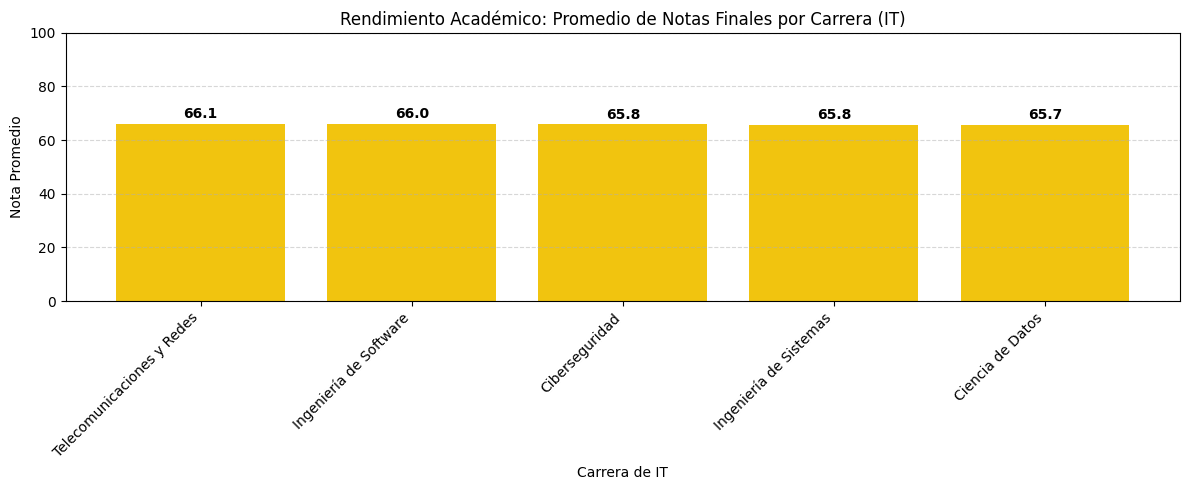

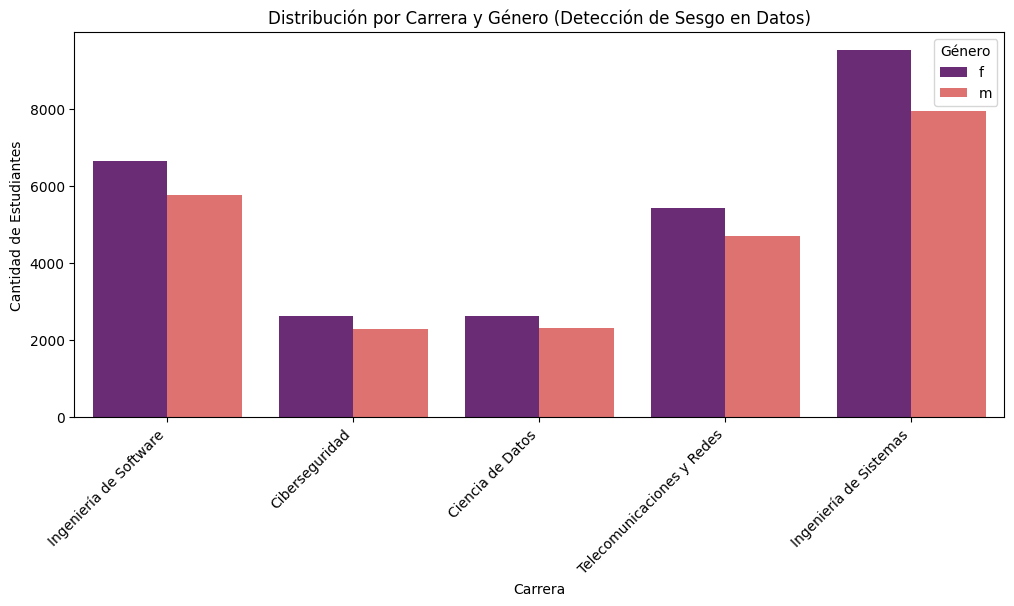

In [5]:
# --- ANÁLISIS 1: Rendimiento Académico por Carrera (Promedio de Notas) ---
df_notas = df_inscripciones.merge(df_carreras, on='CarreraID')
stats_notas = df_notas.groupby('NombreCarrera')['NotaFinal'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 5))
barras = plt.bar(stats_notas['NombreCarrera'], stats_notas['NotaFinal'], color='#f1c40f')

for bar in barras:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, round(yval, 1), ha='center', va='bottom', fontweight='bold')

plt.title('Rendimiento Académico: Promedio de Notas Finales por Carrera (IT)')
plt.xlabel('Carrera de IT')
plt.ylabel('Nota Promedio')
plt.ylim(0, 100) 
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- ANÁLISIS 2: Distribución por Género y Carrera (IT) ---
import seaborn as sns
df_gen = df_estudiantes.merge(df_inscripciones, on='EstudianteID').merge(df_carreras, on='CarreraID')

plt.figure(figsize=(12, 5))
sns.countplot(data=df_gen, x='NombreCarrera', hue='Genero', palette='magma')
plt.title('Distribución por Carrera y Género (Detección de Sesgo en Datos)')
plt.xlabel('Carrera')
plt.ylabel('Cantidad de Estudiantes')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Género')
plt.show()

### Insights de la EDA (IT Focus)

1. **Rendimiento Académico por Carrera**: El primer gráfico muestra el promedio de notas finales en las distintas especialidades de IT. Esto permite identificar si existen carreras con mayor grado de dificultad académica o si el rendimiento es uniforme entre ellas. Un promedio equilibrado sugiere una estandarización en la evaluación, mientras que picos o valles marcarían áreas de atención pedagógica.

2. **Análisis de Género y Calidad de Datos**: El segundo gráfico revela una distribución de género atípica para el sector tecnológico.

**Nota Crítica de BI**: Se identifica un sesgo poco realista en los datos sintéticos generados (`seed.sql`). En el mercado tecnológico real, las carreras de IT suelen estar dominadas por el género masculino. El hecho de que la data muestre una mayoría femenina es un hallazgo importante de **Data Quality**: los datos no están representando fielmente la brecha de género del sector internacional, lo cual debe ser considerado al interpretar los resultados de inserción laboral y brecha de habilidades.

### Conclusiones de la EDA (IT Focus)

1. **Distribución Académica**: Se confirma que las 5 carreras de IT analizadas concentran el volumen principal de la matrícula digital en la UPDS.
2. **Distribución Geográfica**: Se observa una concentración significativa en las ciudades principales, lo cual es consistente con la demanda de conectividad del sector TI.
3. **Tendencia de Matrícula**: El análisis de cohortes muestra el ritmo de nuevos ingresos a lo largo de los años analizados, siendo un indicador clave para proyectar el talento tecnológico del país.
4. **Calidad de Datos**: Los datasets de Estudiantes e Inscripciones para las carreras de IT presentan una integridad sólida, permitiendo avanzar a las fases de cálculo de brecha e inserción laboral.

## 5. Análisis de Calidad de Datos (Data Quality)

Se procede a analizar la presencia de valores nulos en los datasets de Estudiantes e Inscripciones, verificando la integridad de los datos procesados.

In [6]:
print("--- Nulos en Estudiantes ---")
print(df_estudiantes.isnull().sum())

print("\n--- Nulos en Inscripciones ---")
print(df_inscripciones.isnull().sum())

# Cálculo del porcentaje de nulos
null_pct_est = (df_estudiantes.isnull().sum().sum() / df_estudiantes.size) * 100
print(f"\nPorcentaje total de nulos en Estudiantes: {null_pct_est:.2f}%")

--- Nulos en Estudiantes ---
EstudianteID    0
Nombre          0
FechaIngreso    0
Genero          0
Ciudad          0
anio            0
dtype: int64

--- Nulos en Inscripciones ---
InscripcionID     0
EstudianteID      0
CarreraID         0
NotaFinal         0
SemestreActual    0
anio              0
dtype: int64

Porcentaje total de nulos en Estudiantes: 0.00%
